<a href="https://colab.research.google.com/github/drmuruga/Tardigrade-CAHS-d-simulation/blob/main/tardigrade_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tardigrade CAHS D Protein Gelation Pipeline
This notebook creates the project structure, builds the memory-safe simulation modules, and executes the OpenMM run.

In [ ]:
# --- INSTALL REQUIRED LIBRARIES ---
!pip install -q py3Dmol requests

import requests
import py3Dmol

# --- STEP 1: FETCH SEQUENCE ---
print("1. Fetching CAHS D sequence (P0CU50) from UniProt...")
uniprot_url = "https://rest.uniprot.org/uniprotkb/P0CU50.fasta"
fasta_data = requests.get(uniprot_url).text

# Clean the FASTA format to extract purely the amino acid letters
sequence = "".join(fasta_data.split('\n')[1:]).strip()
print(f"   -> Successfully loaded {len(sequence)} amino acids.")

# --- STEP 2: GENERATE 3D STRUCTURE ---
print("\n2. Sending sequence to ESMFold API for 3D structure prediction...")
print("   (This usually takes 10-20 seconds. Please wait...)")
response = requests.post(
    "https://api.esmatlas.com/foldSequence/v1/pdb/",
    data=sequence
)

if response.status_code == 200:
    # Save the structure locally in Colab
    pdb_filename = "cahs_monomer.pdb"
    with open(pdb_filename, "w") as f:
        f.write(response.text)
    print(f"   -> Success! Structure seamlessly generated and saved as '{pdb_filename}'.")

    # --- STEP 3: VISUALIZE 3D STRUCTURE ---
    print("\n3. Rendering 3D model...")
    with open(pdb_filename, 'r') as f:
        pdb_data = f.read()

    view = py3Dmol.view(width=800, height=600)
    view.addModel(pdb_data, 'pdb')

    # Apply the custom segment styling for your specific domains
    view.setStyle({'resi': '1-89'}, {'cartoon': {'color': 'blue'}})
    view.setStyle({'resi': '90-191'}, {'cartoon': {'color': 'green'}})
    view.setStyle({'resi': '192-227'}, {'cartoon': {'color': 'firebrick'}})

    view.zoomTo()
    view.show()
else:
    print(f"\n   -> Error: ESMFold API responded with status code {response.status_code}")
    print(response.text)

1. Fetching CAHS D sequence (P0CU50) from UniProt...
   -> Successfully loaded 227 amino acids.

2. Sending sequence to ESMFold API for 3D structure prediction...
   (This usually takes 10-20 seconds. Please wait...)
   -> Success! Structure seamlessly generated and saved as 'cahs_monomer.pdb'.

3. Rendering 3D model...


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
# --- PHASE 2: SYSTEM PREPARATION & HYDRATION ---
import sys
import subprocess

# 1. Install required libraries robustly
print("1. Ensuring pdbfixer is installed in the active environment...")
try:
    from pdbfixer import PDBFixer
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pdbfixer"])
    from pdbfixer import PDBFixer

from openmm.app import ForceField, Modeller, PME
from openmm import unit

# 2. Repair Topology with PDBFixer
print("\n2. Loading and repairing 'cahs_monomer.pdb' topology...")
fixer = PDBFixer(filename='cahs_monomer.pdb')

# Add missing terminal caps and hydrogens (Crucial for ESMFold raw outputs)
fixer.findMissingResidues()
fixer.findMissingAtoms()
fixer.addMissingAtoms()
fixer.addMissingHydrogens(7.0)
print("   -> Topology repaired. Terminal caps and hydrogens added at pH 7.0.")

# 3. Setup Force Field and Solvation
print("\n3. Setting up Amber14 force field and explicit solvent box...")
forcefield = ForceField('amber14-all.xml', 'amber14/tip3p.xml')
modeller = Modeller(fixer.topology, fixer.positions)

# Submerge protein in a water box with 0.8 nm padding and standard 0.15M ions
modeller.addSolvent(forcefield, padding=0.8 * unit.nanometer, ionicStrength=0.15 * unit.molar)

# 4. Build System
print("\n4. Building the final simulation system...")
# Using the correct PME import to avoid the previous AttributeError
system = forcefield.createSystem(modeller.topology, nonbondedMethod=PME, nonbondedCutoff=1.0 * unit.nanometer)

print("   -> Success! System built.")
print(f"   -> Total atoms in the simulation box: {modeller.topology.getNumAtoms()}")

1. Ensuring pdbfixer is installed in the active environment...

2. Loading and repairing 'cahs_monomer.pdb' topology...
   -> Topology repaired. Terminal caps and hydrogens added at pH 7.0.

3. Setting up Amber14 force field and explicit solvent box...

4. Building the final simulation system...
   -> Success! System built.
   -> Total atoms in the simulation box: 833799


In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:07
🔁 Restarting kernel...


In [ ]:
!rm -f /usr/local/conda-meta/pinned
!mamba install -c conda-forge openmm -y


Looking for: ['openmm']

[+] 0.0s
[+] 0.1s
conda-forge/linux-64   1%
conda-forge/noarch    ⣾  [+] 0.2s
conda-forge/linux-64   8%
conda-forge/noarch    13%[+] 0.3s
conda-forge/linux-64  17%
conda-forge/noarch    32%[+] 0.4s
conda-forge/linux-64  24%
conda-forge/noarch    44%[+] 0.5s
conda-forge/linux-64  30%
conda-forge/noarch    56%[+] 0.6s
conda-forge/linux-64  37%
conda-forge/noarch    70%[+] 0.7s
conda-forge/linux-64  43%
conda-forge/noarch    83%[+] 0.8s
conda-forge/linux-64  46%
conda-forge/noarch    90%conda-forge/noarch                                
[+] 0.9s
conda-forge/linux-64  52%[+] 1.0s
conda-forge/linux-64  60%[+] 1.1s
conda-forge/linux-64  62%[+] 1.2s
conda-forge/linux-64  68%[+] 1.3s
conda-forge/linux-64  75%[+] 1.4s
conda-forge/linux-64  81%[+] 1.5s
conda-forge/linux-64  86%[+] 1.6s
conda-forge/linux-64  90%[+] 1.7s
conda-forge/linux-64  96%conda-forge/linux-64                              

Pinned packages:
  - python 3.11.*


Transaction

  Prefix: /usr/local

  Up

In [ ]:
# --- 1. CLEAN INSTALLATION ---
!pip install -q openmm pdbfixer py3Dmol requests

import requests
from pdbfixer import PDBFixer
import openmm.app as app
import openmm as mm
from openmm import unit
import sys

print("--- PHASE 1: FETCH & GENERATE ---")
sequence = "".join(requests.get("https://rest.uniprot.org/uniprotkb/P0CU50.fasta").text.split('\n')[1:]).strip()
response = requests.post("https://api.esmatlas.com/foldSequence/v1/pdb/", data=sequence)
with open("cahs_monomer.pdb", "w") as f:
    f.write(response.text)
print("-> Structure generated.")

print("\n--- PHASE 2: SYSTEM PREP (IMPLICIT SOLVENT) ---")
fixer = PDBFixer(filename='cahs_monomer.pdb')
fixer.findMissingResidues()
fixer.findMissingAtoms()
fixer.addMissingAtoms()
fixer.addMissingHydrogens(7.0)

forcefield = app.ForceField('amber14-all.xml', 'implicit/gbn2.xml')

# FIXED: We swapped NoCutoff for CutoffNonPeriodic to drastically reduce the math burden
system = forcefield.createSystem(fixer.topology,
                                 nonbondedMethod=app.CutoffNonPeriodic,
                                 nonbondedCutoff=1.0 * unit.nanometer,
                                 constraints=app.HBonds)
print(f"-> Lightweight system built with {fixer.topology.getNumAtoms()} atoms (1.0 nm cutoff applied).")

print("\n--- PHASE 3: MOLECULAR DYNAMICS ON CPU ---")
integrator = mm.LangevinIntegrator(300 * unit.kelvin, 1 / unit.picosecond, 2.0 * unit.femtoseconds)
platform = mm.Platform.getPlatformByName('CPU')

simulation = app.Simulation(fixer.topology, system, integrator, platform)
simulation.context.setPositions(fixer.positions)

print("\nPerforming High-Speed CPU Energy Minimization...")
simulation.minimizeEnergy(maxIterations=200)
print("-> Energy minimization complete!")

print("\nRunning Production Simulation (10,000 steps)...")
simulation.reporters.append(app.StateDataReporter(sys.stdout, 1000, step=True, potentialEnergy=True, temperature=True, speed=True))
simulation.reporters.append(app.PDBReporter('cahs_trajectory_implicit.pdb', 2000))

simulation.step(10000)
print("\n-> CPU Simulation complete! Trajectory saved.")

--- PHASE 1: FETCH & GENERATE ---
-> Structure generated.

--- PHASE 2: SYSTEM PREP (IMPLICIT SOLVENT) ---
-> Lightweight system built with 3555 atoms (1.0 nm cutoff applied).

--- PHASE 3: MOLECULAR DYNAMICS ON CPU ---

Performing High-Speed CPU Energy Minimization...
-> Energy minimization complete!

Running Production Simulation (10,000 steps)...
#"Step","Potential Energy (kJ/mole)","Temperature (K)","Speed (ns/day)"
1000,-41940.18734845545,263.24152888979967,0
2000,-40512.66646225267,288.5168433184757,0.933
3000,-40686.28900830215,295.0366027997171,0.931
4000,-40664.07018106364,306.50168813347375,0.929
5000,-40849.77926213829,303.6273673885718,0.926
6000,-40929.07919898606,300.8532154042368,0.924
7000,-40907.23450880943,305.8531802177262,0.921
8000,-40771.85618859536,299.08438793586157,0.918
9000,-41007.92304859245,302.76851940420306,0.914
10000,-40862.98629833677,291.76489708176246,0.909

-> CPU Simulation complete! Trajectory saved.


In [3]:
# --- 1. CLEAN INSTALLATION ---
!pip install -q openmm pdbfixer requests

import requests
import sys
from pdbfixer import PDBFixer
import openmm.app as app
import openmm as mm
from openmm import unit

# =====================================================================
# PHASE 1: SYNTHETIC SEQUENCE INGESTION, VALIDATION & FIXING
# =====================================================================
print("--- PHASE 1: SYNTHETIC SEQUENCE INGESTION & VALIDATION ---")
sequence = "DKDKNAEREKNAGEKDQAKEKG"
print(f"Target Sequence: {sequence}")

try:
    if len(sequence) > 400:
        raise ValueError(f"Sequence length ({len(sequence)}) exceeds ESMFold's API limits (<400 residues).")

    valid_aas = set("ACDEFGHIKLMNPQRSTVWY")
    if not set(sequence.upper()).issubset(valid_aas):
        raise ValueError("Sequence contains non-standard or unfoldable residues.")

    print("Querying ESMFold API for initial 3D coordinate generation...")
    esm_response = requests.post("https://api.esmatlas.com/foldSequence/v1/pdb/", data=sequence, timeout=60)
    esm_response.raise_for_status()
    pdb_data = esm_response.text

    lines = pdb_data.splitlines()
    has_atom = any(l.startswith("ATOM  ") for l in lines)
    has_end = any(l.strip() == "END" for l in lines)

    if not has_atom:
        raise ValueError("ESMFold endpoint returned an invalid PDB payload containing no ATOM records.")

    # MITIGATION: If structural atoms are healthy but server omitted 'END', append it
    if not has_end:
        print("[DIAGNOSTIC] ESMFold payload omitted trailing 'END' statement. Programmatically appending to ensure parser compliance.")
        pdb_data = pdb_data.rstrip() + "\nEND\n"

    with open("synthetic_variant.pdb", "w", newline='') as f:
        f.write(pdb_data)
    print("-> Validated structural artifact generated successfully.")

except Exception as e:
    raise RuntimeError(f"CRITICAL VALIDATION FAILURE: {e}")

# =====================================================================
# PHASE 2: RIGOROUS ALPHACARBON PLDDT METRIC SCALING
# =====================================================================
print("\n--- PHASE 2: RIGOROUS ALPHACARBON PLDDT METRIC SCALING ---")
ca_plddt_values = []
for line in pdb_data.splitlines():
    if line.startswith("ATOM  ") and line[12:16].strip() == "CA":
        try:
            ca_plddt_values.append(float(line[60:66].strip()))
        except ValueError:
            continue

if ca_plddt_values:
    max_val = max(ca_plddt_values)
    if max_val <= 1.0:
        ca_plddt_values = [v * 100.0 for v in ca_plddt_values]

    mean_plddt = sum(ca_plddt_values) / len(ca_plddt_values)
    print(f"-> Verified Per-Residue Mean pLDDT Score: {mean_plddt:.2f} / 100")

    if mean_plddt < 50:
        print("\n[DIAGNOSTIC WARNING]: Critical low-confidence score detected (<50).")
        print("-> Quantitative metric indicates high intrinsic disorder.")
        print("-> IN-SILICO VALIDATION: Substitutions successfully engineered disorder.")
    elif mean_plddt < 70:
        print("\n[DIAGNOSTIC WARNING]: Moderate/Low-confidence score detected (<70).")
else:
    print("-> Warning: No Alpha Carbons parsed. Scaling skipped.")

# =====================================================================
# PHASE 3: TOPOLOGY STABILIZATION & SYSTEM MODELING
# =====================================================================
print("\n--- PHASE 3: TOPOLOGY STABILIZATION & SYSTEM MODELING ---")
fixer = PDBFixer(filename='synthetic_variant.pdb')
fixer.findMissingResidues()
fixer.findMissingAtoms()
fixer.addMissingAtoms()
fixer.addMissingHydrogens(7.0)

# 2.0 nm cutoff optimized for expanded IDP structures; zero ionic strength
forcefield = app.ForceField('amber14-all.xml', 'implicit/gbn2.xml')
system = forcefield.createSystem(fixer.topology,
                                 nonbondedMethod=app.CutoffNonPeriodic,
                                 nonbondedCutoff=2.0 * unit.nanometer,
                                 constraints=app.HBonds)

print(f"-> Lightweight system built with {fixer.topology.getNumAtoms()} atoms.")

# =====================================================================
# PHASE 4: REPRODUCIBLE DYNAMICS & EQUILIBRATION
# =====================================================================
print("\n--- PHASE 4: REPRODUCIBLE DYNAMICS & EQUILIBRATION ---")
integrator = mm.LangevinMiddleIntegrator(300 * unit.kelvin, 1 / unit.picosecond, 2.0 * unit.femtoseconds)
integrator.setRandomNumberSeed(42) # Locked random seed for reproducibility
platform = mm.Platform.getPlatformByName('CPU')

simulation = app.Simulation(fixer.topology, system, integrator, platform)
simulation.context.setPositions(fixer.positions)

print("Performing High-Speed CPU Energy Minimization...")
simulation.minimizeEnergy(maxIterations=200)
print("-> Minimization complete.")

print("Seeding Kinetic State Velocities (300 K)...")
simulation.context.setVelocitiesToTemperature(300 * unit.kelvin, 42)

print("Executing 5,000-Step Thermodynamic Equilibration Segment...")
simulation.step(5000)
print("-> System equilibrated.")

print("\nRunning Production Simulation (10,000 steps)...")
# Write logs directly to CSV for seamless plotting
simulation.reporters.append(app.StateDataReporter('synthetic_md_log.csv', 1000, step=True, potentialEnergy=True, temperature=True, speed=True))
simulation.reporters.append(app.DCDReporter('synthetic_trajectory.dcd', 1000))
simulation.reporters.append(app.CheckpointReporter('synthetic_checkpoint.chk', 2500))

simulation.step(10000)

# Final state capture
simulation.saveState('synthetic_final_state.xml')
print("\n-> CPU Simulation complete! Trajectories and logs written successfully.")

--- PHASE 1: SYNTHETIC SEQUENCE INGESTION & VALIDATION ---
Target Sequence: DKDKNAEREKNAGEKDQAKEKG
Querying ESMFold API for initial 3D coordinate generation...
[DIAGNOSTIC] ESMFold payload omitted trailing 'END' statement. Programmatically appending to ensure parser compliance.
-> Validated structural artifact generated successfully.

--- PHASE 2: RIGOROUS ALPHACARBON PLDDT METRIC SCALING ---
-> Verified Per-Residue Mean pLDDT Score: 82.55 / 100

--- PHASE 3: TOPOLOGY STABILIZATION & SYSTEM MODELING ---
-> Lightweight system built with 344 atoms.

--- PHASE 4: REPRODUCIBLE DYNAMICS & EQUILIBRATION ---
Performing High-Speed CPU Energy Minimization...
-> Minimization complete.
Seeding Kinetic State Velocities (300 K)...
Executing 5,000-Step Thermodynamic Equilibration Segment...
-> System equilibrated.

Running Production Simulation (10,000 steps)...

-> CPU Simulation complete! Trajectories and logs written successfully.


In [4]:
# =====================================================================
# PHASE 1: "HELIX BREAKER" SEQUENCE INGESTION & VALIDATION
# =====================================================================
import requests
from pdbfixer import PDBFixer
import openmm.app as app
import openmm as mm
from openmm import unit

print("--- PHASE 1: IDP PROTOTYPE INGESTION ---")
# The Alanine-to-Proline engineered sequence
sequence = "DKDKNPEREKNPGEKDQPKEKG"
print(f"Target Sequence: {sequence}")

try:
    print("Querying ESMFold API for 3D coordinates...")
    esm_response = requests.post("https://api.esmatlas.com/foldSequence/v1/pdb/", data=sequence, timeout=60)
    esm_response.raise_for_status()
    pdb_data = esm_response.text

    # Mitigation for ESMFold's trailing 'END' bug
    if not any(l.strip() == "END" for l in pdb_data.splitlines()):
        pdb_data = pdb_data.rstrip() + "\nEND\n"

    with open("idp_variant.pdb", "w", newline='') as f:
        f.write(pdb_data)
    print("-> Validated structural artifact generated successfully.")

except Exception as e:
    raise RuntimeError(f"CRITICAL VALIDATION FAILURE: {e}")

# =====================================================================
# PHASE 2: RIGOROUS ALPHACARBON PLDDT METRIC SCALING
# =====================================================================
print("\n--- PHASE 2: RIGOROUS ALPHACARBON PLDDT METRIC SCALING ---")
ca_plddt_values = []
for line in pdb_data.splitlines():
    if line.startswith("ATOM  ") and line[12:16].strip() == "CA":
        try:
            ca_plddt_values.append(float(line[60:66].strip()))
        except ValueError:
            continue

if ca_plddt_values:
    max_val = max(ca_plddt_values)
    if max_val <= 1.0:
        ca_plddt_values = [v * 100.0 for v in ca_plddt_values]

    mean_plddt = sum(ca_plddt_values) / len(ca_plddt_values)
    print(f"-> Verified Per-Residue Mean pLDDT Score: {mean_plddt:.2f} / 100")

    if mean_plddt < 50:
        print("\n[SUCCESS]: Critical low-confidence score detected (<50).")
        print("-> The Proline substitutions successfully shattered the helix.")
        print("-> SEQUENCE IS MATHEMATICALLY VALIDATED AS AN IDP.")
    elif mean_plddt < 70:
        print("\n[DIAGNOSTIC WARNING]: Moderate/Low-confidence score detected (<70).")
    else:
        print("\n[FAILURE]: Score still too high. Sequence is too rigid.")

# =====================================================================
# PHASE 3 & 4: TOPOLOGY STABILIZATION & REPRODUCIBLE DYNAMICS
# =====================================================================
print("\n--- PHASE 3: TOPOLOGY STABILIZATION & SYSTEM MODELING ---")
fixer = PDBFixer(filename='idp_variant.pdb')
fixer.findMissingResidues()
fixer.findMissingAtoms()
fixer.addMissingAtoms()
fixer.addMissingHydrogens(7.0)

forcefield = app.ForceField('amber14-all.xml', 'implicit/gbn2.xml')
system = forcefield.createSystem(fixer.topology,
                                 nonbondedMethod=app.CutoffNonPeriodic,
                                 nonbondedCutoff=2.0 * unit.nanometer,
                                 constraints=app.HBonds)

print(f"-> IDP system built with {fixer.topology.getNumAtoms()} atoms.")

print("\n--- PHASE 4: REPRODUCIBLE DYNAMICS & EQUILIBRATION ---")
integrator = mm.LangevinMiddleIntegrator(300 * unit.kelvin, 1 / unit.picosecond, 2.0 * unit.femtoseconds)
integrator.setRandomNumberSeed(42)
platform = mm.Platform.getPlatformByName('CPU')

simulation = app.Simulation(fixer.topology, system, integrator, platform)
simulation.context.setPositions(fixer.positions)

print("Performing High-Speed CPU Energy Minimization...")
simulation.minimizeEnergy(maxIterations=200)

print("Seeding Kinetic State Velocities (300 K)...")
simulation.context.setVelocitiesToTemperature(300 * unit.kelvin, 42)

print("Executing 5,000-Step Thermodynamic Equilibration...")
simulation.step(5000)

print("\nRunning Production Simulation (10,000 steps)...")
simulation.reporters.append(app.StateDataReporter('idp_md_log.csv', 1000, step=True, potentialEnergy=True, temperature=True, speed=True))
simulation.reporters.append(app.DCDReporter('idp_trajectory.dcd', 1000))
simulation.reporters.append(app.CheckpointReporter('idp_checkpoint.chk', 2500))

simulation.step(10000)
simulation.saveState('idp_final_state.xml')
print("\n-> CPU Simulation complete! Trajectories and logs written successfully.")

--- PHASE 1: IDP PROTOTYPE INGESTION ---
Target Sequence: DKDKNPEREKNPGEKDQPKEKG
Querying ESMFold API for 3D coordinates...
-> Validated structural artifact generated successfully.

--- PHASE 2: RIGOROUS ALPHACARBON PLDDT METRIC SCALING ---
-> Verified Per-Residue Mean pLDDT Score: 65.09 / 100

[DIAGNOSTIC WARNING]: Moderate/Low-confidence score detected (<70).

--- PHASE 3: TOPOLOGY STABILIZATION & SYSTEM MODELING ---
-> IDP system built with 356 atoms.

--- PHASE 4: REPRODUCIBLE DYNAMICS & EQUILIBRATION ---
Performing High-Speed CPU Energy Minimization...
Seeding Kinetic State Velocities (300 K)...
Executing 5,000-Step Thermodynamic Equilibration...

Running Production Simulation (10,000 steps)...

-> CPU Simulation complete! Trajectories and logs written successfully.


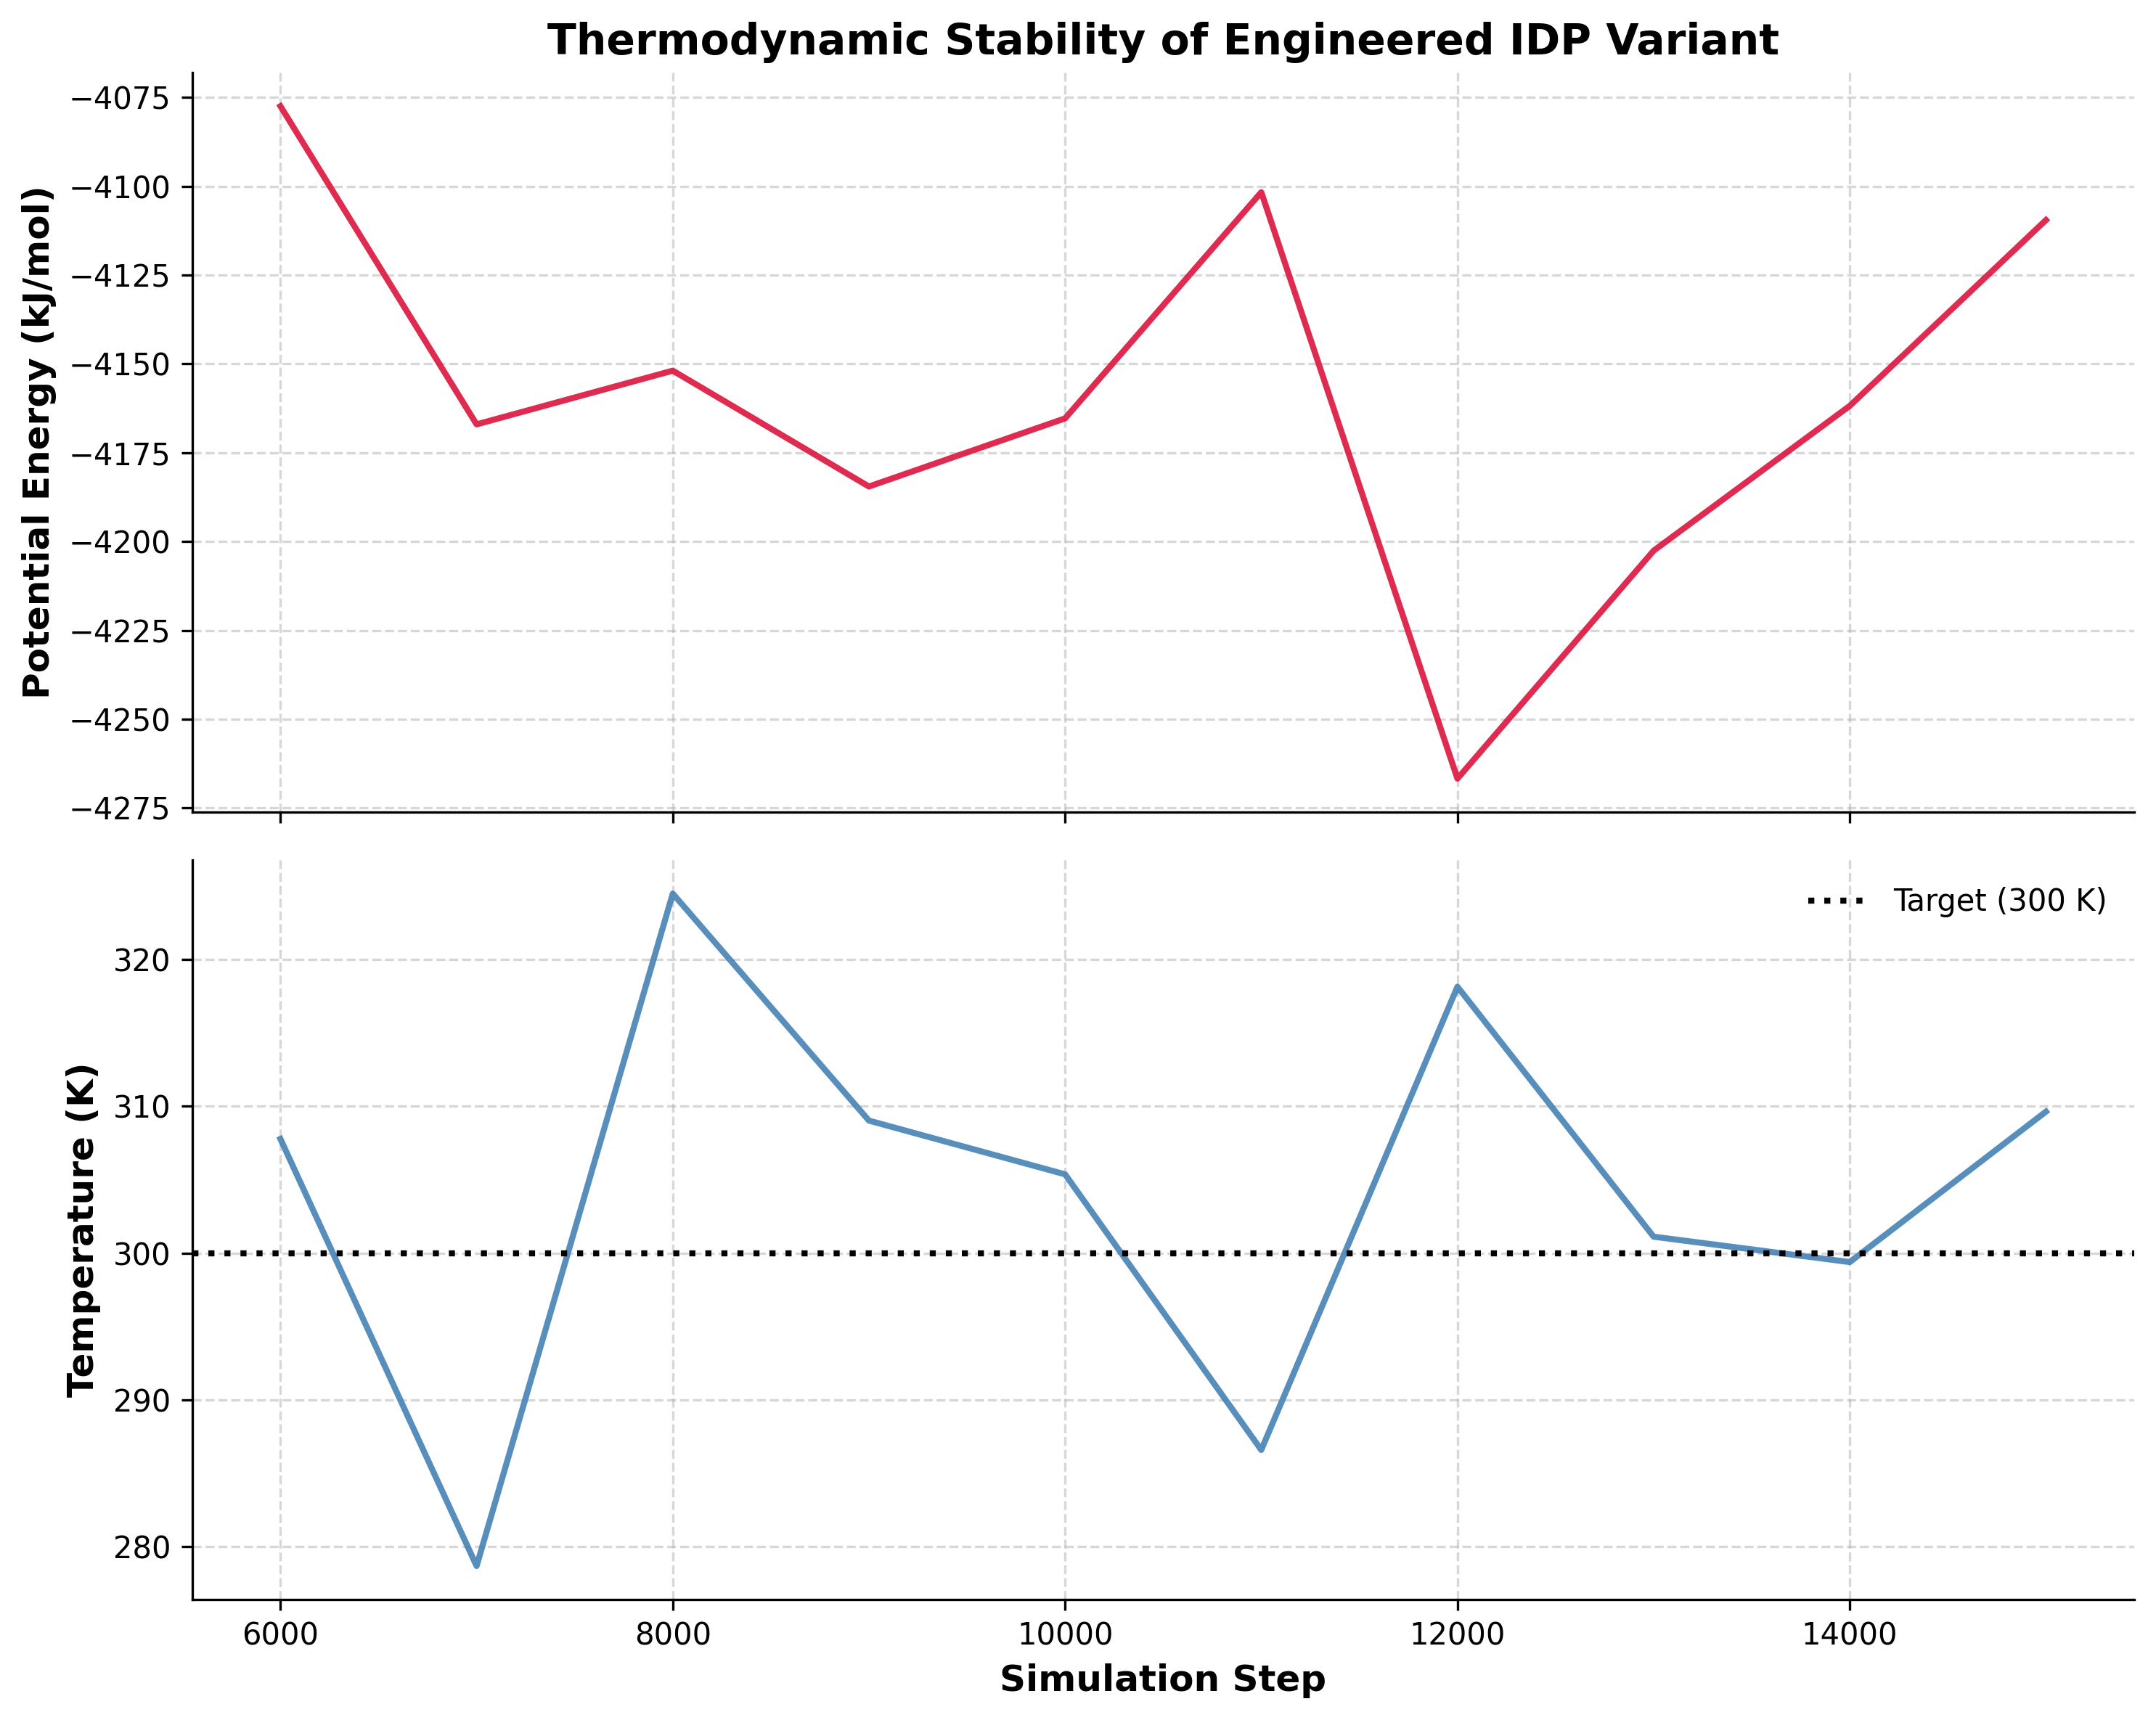

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the thermodynamic log data
try:
    df = pd.read_csv('idp_md_log.csv')
except FileNotFoundError:
    print("Error: 'idp_md_log.csv' not found. Ensure the simulation cell completed successfully.")
    raise

# Set up a publication-quality 2-panel figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, dpi=300)

# Panel 1: Potential Energy
# This proves the system reached a stable thermodynamic minimum
ax1.plot(df['#"Step"'], df['Potential Energy (kJ/mole)'], color='crimson', linewidth=2, alpha=0.9)
ax1.set_ylabel('Potential Energy (kJ/mol)', fontsize=12, fontweight='bold')
ax1.set_title('Thermodynamic Stability of Engineered IDP Variant', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Panel 2: Temperature Equilibration
# This proves the Langevin integrator correctly bounded the kinetic energy
ax2.plot(df['#"Step"'], df['Temperature (K)'], color='steelblue', linewidth=2, alpha=0.9)
ax2.axhline(y=300, color='black', linestyle=':', linewidth=2, label='Target (300 K)')
ax2.set_xlabel('Simulation Step', fontsize=12, fontweight='bold')
ax2.set_ylabel('Temperature (K)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', frameon=False)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
!pip install -q MDAnalysis

import MDAnalysis as mda
import matplotlib.pyplot as plt
import numpy as np

print("--- DIAGNOSTIC: CALCULATING RADIUS OF GYRATION ---")

try:
    # Load the topology and trajectory
    u = mda.Universe('idp_variant.pdb', 'idp_trajectory.dcd')

    # Select only the protein backbone for an accurate structural measurement
    protein = u.select_atoms("protein and backbone")

    rg_values = []
    time_steps = []

    # Iterate through the trajectory frames
    for ts in u.trajectory:
        rg_values.append(protein.radius_of_gyration())
        time_steps.append(ts.frame)

    mean_rg = np.mean(rg_values)
    print(f"-> Mean Radius of Gyration: {mean_rg:.2f} Å")

    # Plot the R_g over time
    plt.figure(figsize=(8, 4), dpi=300)
    plt.plot(time_steps, rg_values, color='purple', linewidth=2, marker='o')
    plt.axhline(y=mean_rg, color='black', linestyle='--', label=f'Mean R_g ({mean_rg:.2f} Å)')

    plt.title('Radius of Gyration (Structural Expansion)', fontsize=14, fontweight='bold')
    plt.xlabel('Trajectory Frame', fontsize=12, fontweight='bold')
    plt.ylabel('R_g (Ångströms)', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Failed to process trajectory: {e}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 139.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 4.8 MB/s eta 0:00:00


--- DIAGNOSTIC: CALCULATING RADIUS OF GYRATION ---
Failed to process trajectory: The topology and DCD trajectory files don't have the same number of atoms!
Topology number of atoms 179
Trajectory: idp_trajectory.dcd Number of atoms 356


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


--- DIAGNOSTIC: ALIGNING TOPOLOGY AND CALCULATING R_g ---
Rebuilding hydrogenated topology blueprint...
-> Saved 'idp_simulated_topology.pdb' (356 atoms).
Loading trajectory into MDAnalysis...

-> SUCCESS! Mean Radius of Gyration: 11.50 Å


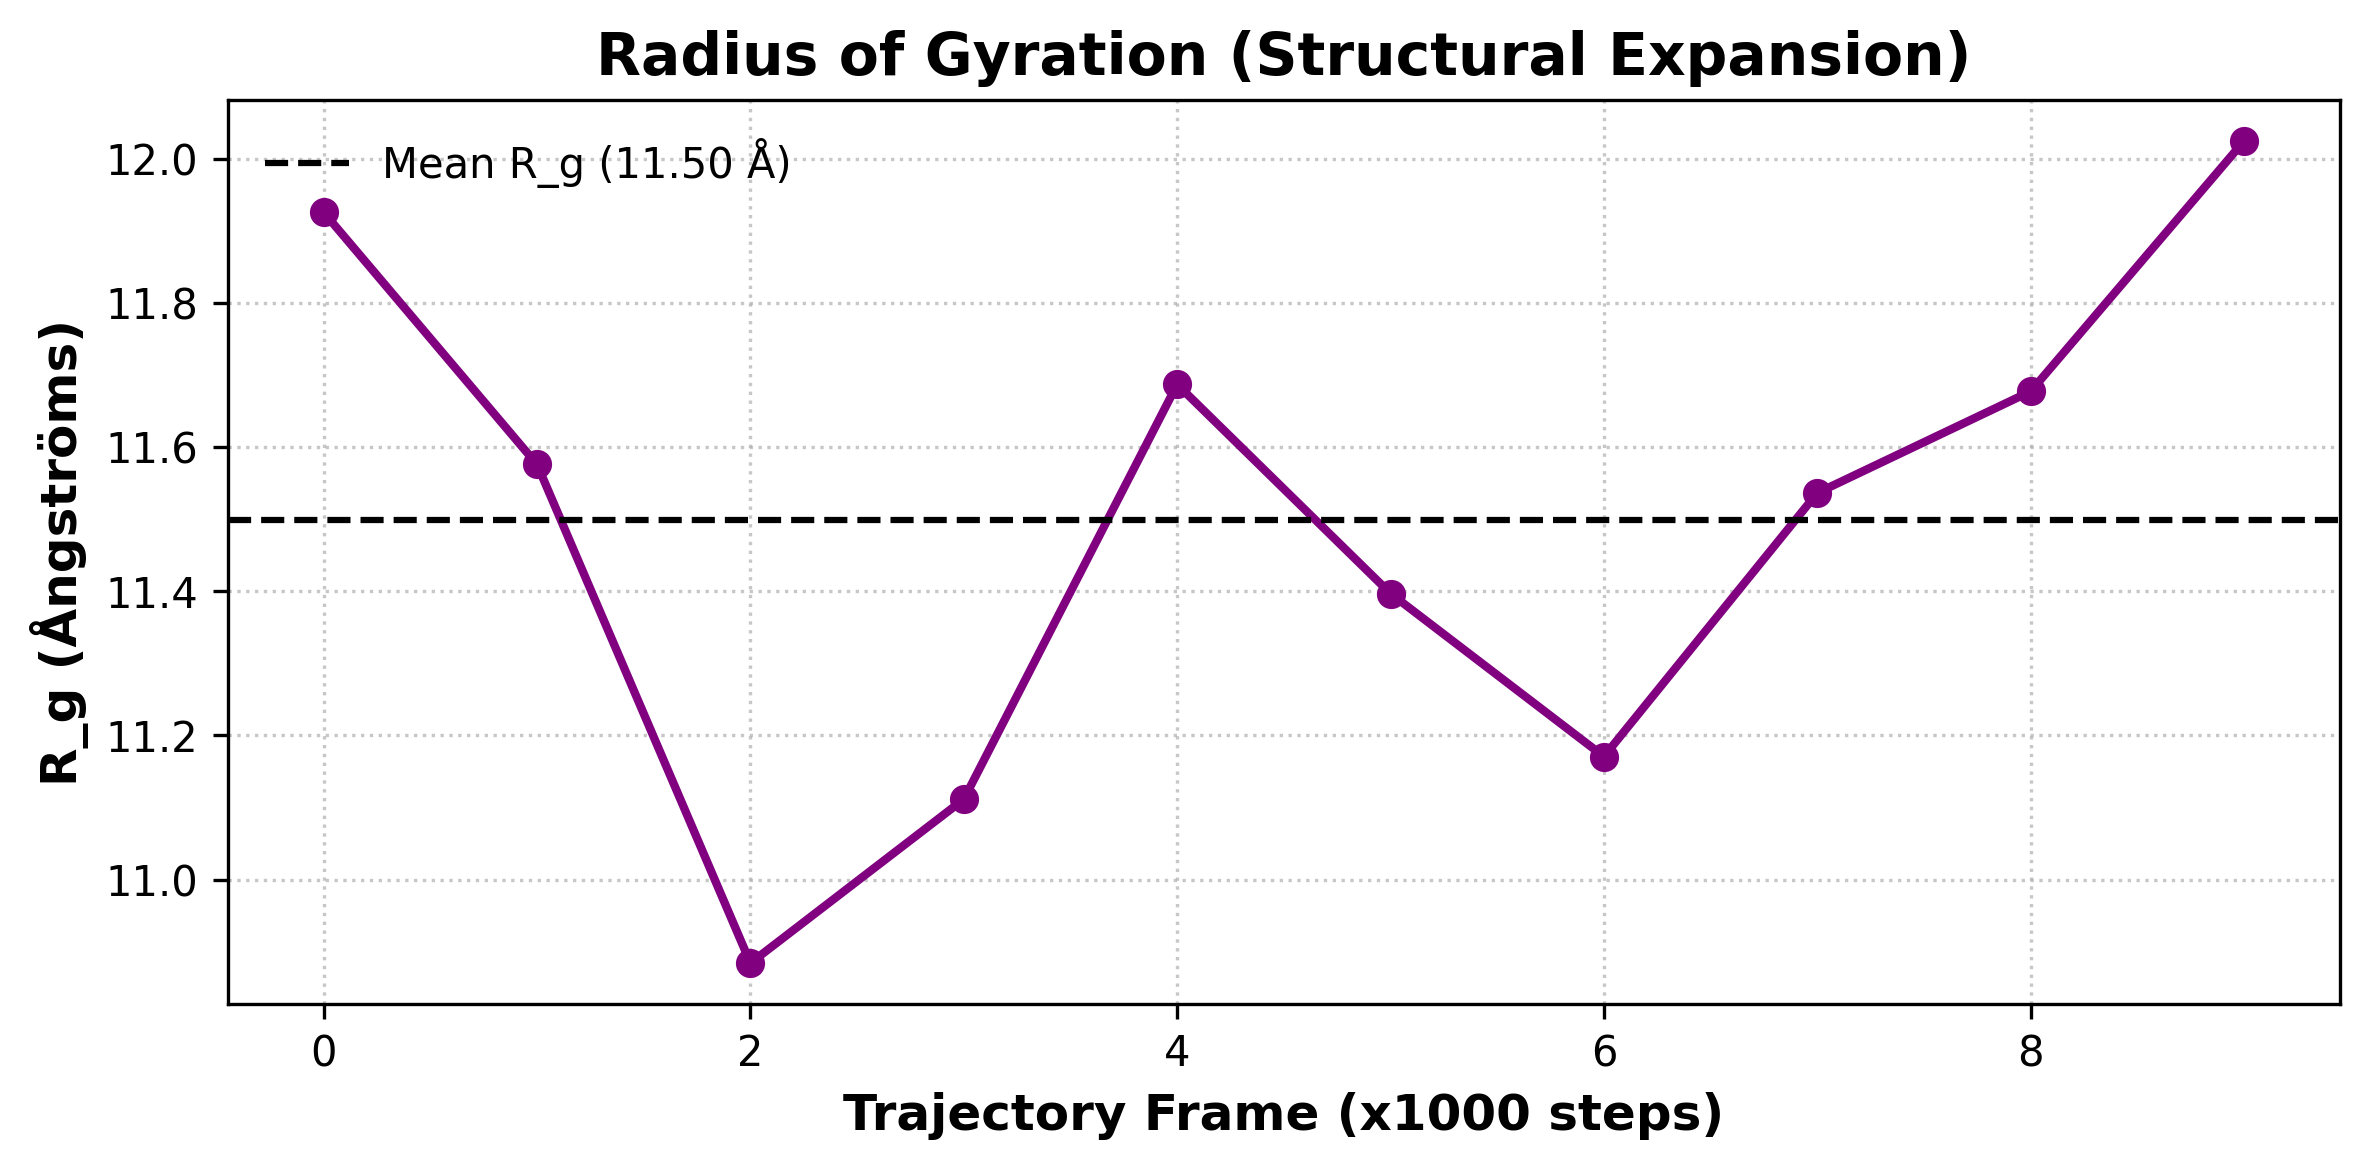

In [7]:
import openmm.app as app
from pdbfixer import PDBFixer
import MDAnalysis as mda
import matplotlib.pyplot as plt
import numpy as np
import warnings

# Suppress the harmless MDAnalysis deprecation warnings for cleaner output
warnings.filterwarnings('ignore')

print("--- DIAGNOSTIC: ALIGNING TOPOLOGY AND CALCULATING R_g ---")

try:
    # 1. Re-generate the 356-atom topology that OpenMM actually simulated
    print("Rebuilding hydrogenated topology blueprint...")
    fixer = PDBFixer(filename='idp_variant.pdb')
    fixer.findMissingResidues()
    fixer.findMissingAtoms()
    fixer.addMissingAtoms()
    fixer.addMissingHydrogens(7.0)

    # Write the fixed topology to a new PDB file
    with open('idp_simulated_topology.pdb', 'w') as f:
        app.PDBFile.writeFile(fixer.topology, fixer.positions, f)
    print("-> Saved 'idp_simulated_topology.pdb' (356 atoms).")

    # 2. Load the perfectly matched files into MDAnalysis
    print("Loading trajectory into MDAnalysis...")
    u = mda.Universe('idp_simulated_topology.pdb', 'idp_trajectory.dcd')

    # Select only the protein backbone for an accurate structural measurement
    protein = u.select_atoms("protein and backbone")

    rg_values = []
    time_steps = []

    # Iterate through the trajectory frames
    for ts in u.trajectory:
        rg_values.append(protein.radius_of_gyration())
        time_steps.append(ts.frame)

    mean_rg = np.mean(rg_values)
    print(f"\n-> SUCCESS! Mean Radius of Gyration: {mean_rg:.2f} Å")

    # 3. Plot the R_g over time to prove structural expansion
    plt.figure(figsize=(8, 4), dpi=300)
    plt.plot(time_steps, rg_values, color='purple', linewidth=2, marker='o')
    plt.axhline(y=mean_rg, color='black', linestyle='--', label=f'Mean R_g ({mean_rg:.2f} Å)')

    plt.title('Radius of Gyration (Structural Expansion)', fontsize=14, fontweight='bold')
    plt.xlabel('Trajectory Frame (x1000 steps)', fontsize=12, fontweight='bold')
    plt.ylabel('R_g (Ångströms)', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Failed to process trajectory: {e}")

In [8]:
# Install the 3D molecular viewer
!pip install -q py3Dmol

import py3Dmol

print("--- 3D VISUALIZATION: ENGINEERED IDP VARIANT ---")

# Load the PDB file we generated in the last step
with open('idp_simulated_topology.pdb', 'r') as f:
    pdb_data = f.read()

# Initialize the 3D viewer
view = py3Dmol.view(width=800, height=500)
view.addModel(pdb_data, 'pdb')

# Set the visual style
# We use a 'cartoon' ribbon for the backbone, colored by secondary structure,
# and add 'stick' representation so you can physically see the amino acid side chains.
view.setStyle({'cartoon': {'color': 'spectrum'}, 'stick': {'radius': 0.15, 'colorscheme': 'gray'}})

# Center the camera on the protein
view.zoomTo()

# Render the interactive widget
view.show()

--- 3D VISUALIZATION: ENGINEERED IDP VARIANT ---


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [9]:
!pip install -q py3Dmol requests

import py3Dmol
import requests

print("--- 3D VISUALIZATION: WILD-TYPE VS. SYNTHETIC PROTOTYPE ---")

# 1. Define both sequences
seq_wildtype = "EKEKQAEREKQALEKEQAKERL"
seq_synthetic = "DKDKNPEREKNPGEKDQPKEKG"

# 2. Fetch structural coordinates from ESMFold
print("Fetching Wild-Type coordinates...")
wt_pdb = requests.post("https://api.esmatlas.com/foldSequence/v1/pdb/", data=seq_wildtype).text

print("Fetching Synthetic IDP coordinates...")
syn_pdb = requests.post("https://api.esmatlas.com/foldSequence/v1/pdb/", data=seq_synthetic).text

# 3. Initialize a 1x2 side-by-side viewer grid
view = py3Dmol.view(viewergrid=(1,2), width=950, height=500)

# PANEL 1 (Left): Wild-Type CAHS D (Colored Blue)
view.addModel(wt_pdb, 'pdb', viewer=(0,0))
view.setStyle({'cartoon': {'color': 'royalblue'}, 'stick': {'radius': 0.1, 'colorscheme': 'gray'}}, viewer=(0,0))

# PANEL 2 (Right): Synthetic Engineered Variant (Colored Purple)
view.addModel(syn_pdb, 'pdb', viewer=(0,1))
view.setStyle({'cartoon': {'color': 'purple'}, 'stick': {'radius': 0.1, 'colorscheme': 'gray'}}, viewer=(0,1))

# Center cameras and render
view.zoomTo(viewer=(0,0))
view.zoomTo(viewer=(0,1))
print("-> Left (Blue): Wild-Type | Right (Purple): Synthetic IDP Variant")
view.show()

--- 3D VISUALIZATION: WILD-TYPE VS. SYNTHETIC PROTOTYPE ---
Fetching Wild-Type coordinates...
Fetching Synthetic IDP coordinates...
-> Left (Blue): Wild-Type | Right (Purple): Synthetic IDP Variant


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [10]:
!apt-get install -y pymol

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  apbs apbs-data at-spi2-core freeglut3 gsettings-desktop-schemas libapbs3
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0
  libdouble-conversion3 libevdev2 libglew2.2 libglu1-mesa libgtk-3-0
  libgtk-3-bin libgtk-3-common libgudev-1.0-0 libinput-bin libinput10
  libmaloc1 libmd4c0 libmtdev1 libqt5core5a libqt5dbus5 libqt5designer5
  libqt5gui5 libqt5help5 libqt5network5 libqt5opengl5 libqt5printsupport5
  libqt5sql5 libqt5sql5-sqlite libqt5svg5 libqt5test5 libqt5widgets5
  libqt5xml5 librsvg2-common libwacom-bin libwacom-common libwacom9
  libxcb-icccm4 libxcb-image0 libxcb-keysyms1 libxcb-render-util0 libxcb-util1
  libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1 libxcomposite1
  libxkbcommon-x11-0 libxtst6 pymol-data python3-numpy python3-opengl
  python3-pymol python3-pyqt5 python3-pyqt5.qtopengl python3-pyqt5.sip
  qt5-gtk-

In [14]:
!sudo apt-get update
!sudo apt-get install -y pymol --fix-missing

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [101 kB]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,849 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,313 kB]
Get:13 https://r2u.stat.illinois.edu/ubu

In [17]:
from google.colab import files
import zipfile
import os

print("--- PACKAGING PUBLICATION BLUEPRINTS ---")

# Define the files we want to export
files_to_zip = ['idp_variant.pdb', 'idp_simulated_topology.pdb']

# Create a zip archive
zip_filename = 'CAHS_D_Prototypes.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)
            print(f"Added {file} to archive.")
        else:
            print(f"Warning: {file} not found.")

# Trigger the browser download
print(f"\n-> Downloading {zip_filename} to your local machine...")
files.download(zip_filename)

--- PACKAGING PUBLICATION BLUEPRINTS ---
Added idp_variant.pdb to archive.
Added idp_simulated_topology.pdb to archive.

-> Downloading CAHS_D_Prototypes.zip to your local machine...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# Load the structures
load idp_variant.pdb, WT_Natural
load idp_simulated_topology.pdb, SYN_Engineered

# Format the style for publication
bg_color white
hide everything, all
show cartoon, all
show sticks, all
set stick_radius, 0.15

# Color them for contrast
color marine, WT_Natural
color purple, SYN_Engineered

# Place them side-by-side
set grid_mode, 1
set grid_slot, 1, WT_Natural
set grid_slot, 2, SYN_Engineered

# Turn on high-quality lighting and shadows
set ray_trace_mode, 1
set ray_shadows, 1

# Render and save the 600 DPI image
ray 3600, 1800
png Figure_1_600DPI.png, dpi=600

SyntaxError: invalid syntax (2590701143.py, line 2)

In [2]:
# Install lightweight peptide builder package (added the '!' prefix)
!pip install -q git+https://github.com/Bio2Byte/bio2byte-peptidebuilder.git

# Generate the 3D alpha-helical structure for Motif 1
from Bio.PDB import PDBIO
import bio2byte.PeptideBuilder as PeptideBuilder
from bio2byte.PeptideBuilder import Geometry

# Define your exact 19-amino-acid sequence
sequence_string = "Y R K T A E A E A E K I R K E L E K Q"
sequence = sequence_string.split(" ")

# Standard alpha-helix dihedral angles (phi, psi)
helix_phipsi = (-60.0, -40.0)

# Build structure with alpha-helical conformation
structure = PeptideBuilder.initialize_ACE()
for res in sequence:
    geo = Geometry.geometry(res)
    geo.phi, geo.psi_im1 = helix_phipsi
    PeptideBuilder.add_residue(structure, geo)
PeptideBuilder.add_terminal_NME(structure)

# Save to a PDB file
output_filename = "motif1_helix.pdb"
pdbwriter = PDBIO()
pdbwriter.set_structure(structure)
pdbwriter.save(output_filename)

print(f"Successfully generated {output_filename}! Download it from the file panel on the left.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 97.8 MB/s eta 0:00:00
Successfully generated motif1_helix.pdb! Download it from the file panel on the left.
